<a href="https://colab.research.google.com/github/Mugetsu-Nuckie/dzstatprac/blob/main/dz2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework

## Problem 1

Let $f(x) = 2\sin x - \cos{2x}$. Write a function `beauty_derivative_plot` that takes a point $x$ and plots the function $f(x)$ and its derivative $f'(x)$ in the range $x \in [-2\pi, 2\pi]$. The function should also plot the tangent line to the function at the point $x$.

Example of output for $x = -3, -2, 1.7$:

```python
beauty_derivative_plot(-3)
```
<img src="https://i.ibb.co/zTdYLC0J/tangent-line-3-0.png" width="600"/>

```python
beauty_derivative_plot(-2)
```
<img src="https://i.ibb.co/hFXNZ7wS/tangent-line-2-0.png" width="600"/>

```python
beauty_derivative_plot(1.7)
```
<img src="https://i.ibb.co/217yHstn/tangent-line-1-7.png" width="600"/>

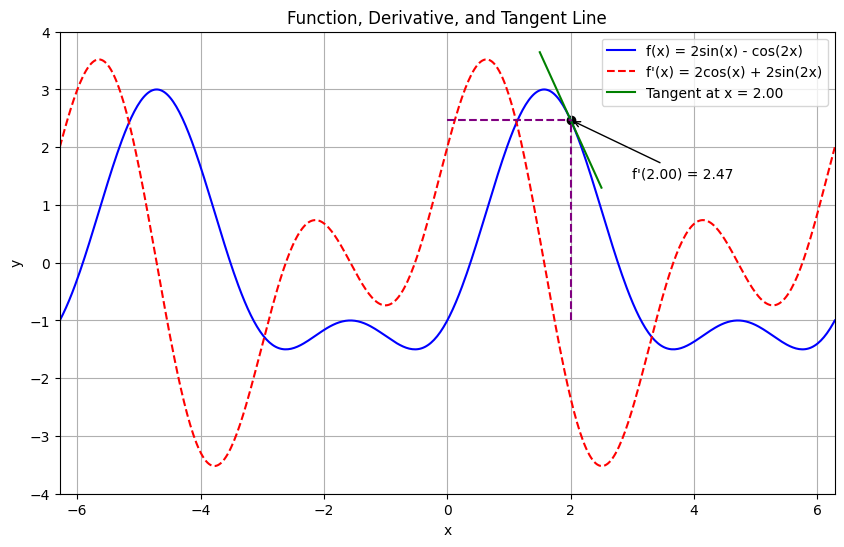

In [4]:
import numpy as np
import matplotlib.pyplot as plt
def beauty_derivative_plot(x0):
    def f(x):

        return 2 * np.sin(x) - np.cos(2*x)

    def df(x):

        return 2 * np.cos(x) + 2* np.sin(2*x)

    x = np.linspace(-2* np.pi, 2* np.pi, 500)
    y=f(x)
    dy=df(x)
    y0=f(x0)
    dy0=df(x0)
    kasatel= y0+ dy0 * (x-x0)

    plt.figure(figsize=(10, 6))
    plt.plot(x,y, label ="f(x) = 2sin(x) - cos(2x)", color = "blue")
    plt.plot(x,dy, "--", label ="f'(x) = 2cos(x) + 2sin(2x)", color = "red")
    dlina = 0.5
    x_dlina = np.linspace(max(x0 - dlina, x[0]), min(x0 + dlina, x[-1]), 100)
    y_dlina = y0 + dy0 * (x_dlina - x0)
    plt.plot(x_dlina, y_dlina, label=f"Tangent at x = {x0:.2f}", color="green")
    plt.scatter(x0, y0, color = "black")

    plt.vlines(x0, -1, y0, colors="purple", linestyles="--")
    plt.hlines(y0, 0, x0, colors="purple", linestyles="--")

    plt.annotate(f"f'({x0:.2f}) = {y0:.2f}", xy=(x0, y0), xytext=(x0+1, y0-1), arrowprops=dict(arrowstyle="->"))

    plt.title("Function, Derivative, and Tangent Line")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.xlim(-2*np.pi, 2*np.pi)
    plt.ylim(-4, 4)
    plt.show()
beauty_derivative_plot(2)

## Problem 2

The data in [populations.txt](http://www.scipy-lectures.org/_downloads/populations.txt) describes the populations of hares, lynxes and carrots in northern Canada during 20 years. Get the data with
```python
np.loadtxt('http://www.scipy-lectures.org/_downloads/populations.txt')
```
and do the following exercises **without for-loops (!!!)**.

- Plot the population size of each species for each year on a single graph. Add legend and axis labels to the plot.

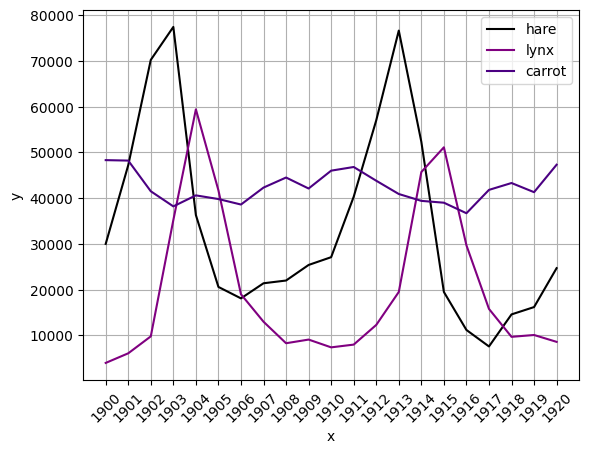

In [31]:
import numpy as np
import matplotlib.pyplot as plt
data = np.loadtxt('populations.txt')
column1 = data[:, 0]
column2 = data[:, 1]
column3 = data[:, 2]
column4 = data[:, 3]
plt.plot(column1, column2, "black", label = "hare")
plt.plot(column1, column3, "purple", label = "lynx")
plt.plot(column1, column4, "indigo", label = "carrot")
plt.legend(loc="best")
plt.xlabel('x')
plt.ylabel('y')
plt.xticks(column1, rotation=45)
plt.grid(True)

- Find which year each species had the largest population. Mark these years in the plot of populations.

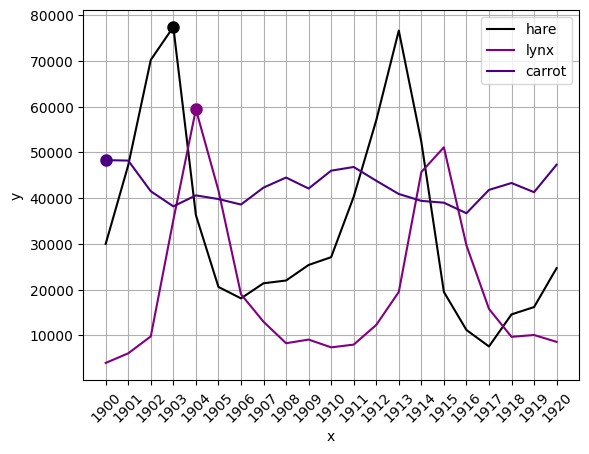

In [30]:
data = np.loadtxt('populations.txt')
column1 = data[:, 0]
column2 = data[:, 1]
column3 = data[:, 2]
column4 = data[:, 3]
plt.plot(column1, column2, "black", label = "hare")
plt.plot(column1, column3, "purple", label = "lynx")
plt.plot(column1, column4, "indigo", label = "carrot")
plt.legend(loc="best")
plt.xlabel('x')
plt.ylabel('y')
plt.xticks(column1, rotation=45)
plt.grid(True)

column2.max()
idx2 = column2.argmax()
plt.plot(column1[idx2], column2[idx2],  color='black', marker='o', linestyle='', markersize=8)
column3.max()
idx3 = column3.argmax()
plt.plot(column1[idx3], column3[idx3], color='purple', marker='o', linestyle='', markersize=8)
column4.max()
idx4 = column4.argmax()
plt.plot(column1[idx4], column4[idx4], color='indigo', marker='o', linestyle='', markersize=8)

- Assuming total population of hares and lynxes is 100%, plot stacked bar graph showing ratio of each specis for each year in the period.

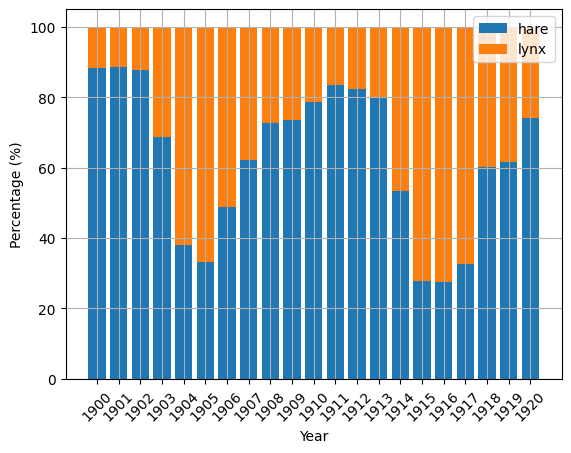

In [26]:
data = np.loadtxt('populations.txt')
column1 = data[:, 0]
column2 = data[:, 1]
column3 = data[:, 2]
column4 = data[:, 3]
total = column2 + column3
hare_ratio = column2 / total * 100
lynx_ratio = column3 / total * 100
plt.bar(column1, hare_ratio, label="hare")
plt.bar(column1, lynx_ratio, bottom=hare_ratio, label="lynx")
plt.grid(True)
plt.legend()
plt.xlabel("Year")
plt.ylabel("Percentage (%)")
plt.xticks(column1, rotation=45)
plt.show()


- Find the mean and std of the populations of each species. Plot the historgam of population for each species and show mean values with vertical line. Show each histogram in a separate plot. Arrange 3 plots in a row.

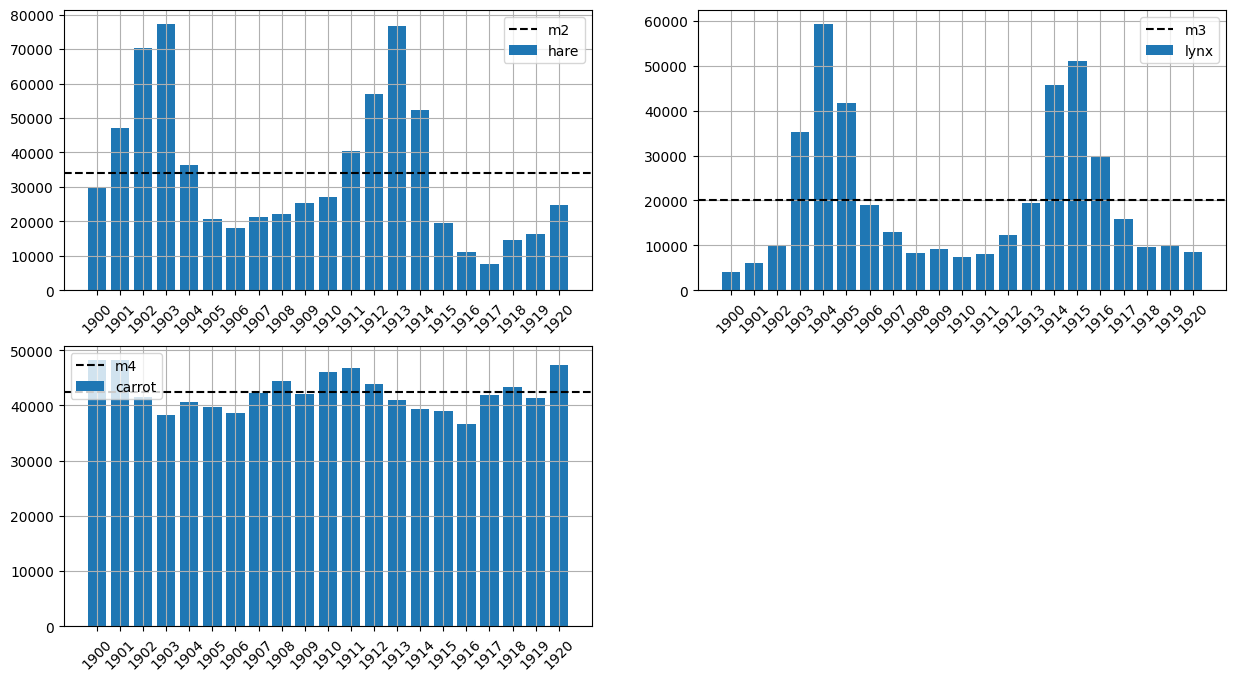

In [36]:
data = np.loadtxt('populations.txt')
column1 = data[:, 0]
column2 = data[:, 1]
column3 = data[:, 2]
column4 = data[:, 3]
m2 = column2.mean()
m3 = column3.mean()
m4 = column4.mean()
D2 = column2.std()
D3 = column3.std()
D4 = column4.std()
plt.figure(figsize=(15, 8))
plt.subplot(2, 2, 1)
plt.bar(column1, column2, label="hare")
plt.grid(True)
plt.xticks(column1, rotation=45)
plt.axhline(m2, linestyle='--', color='black', label = "m2")
plt.legend()
plt.subplot(2, 2, 2)
plt.bar(column1, column3, label="lynx")
plt.xticks(column1, rotation=45)
plt.axhline(m3, linestyle='--', color='black', label = "m3")
plt.grid(True)
plt.legend()
plt.subplot(2, 2, 3)
plt.bar(column1, column4, label="carrot")
plt.xticks(column1, rotation=45)
plt.axhline(m4, linestyle='--', color='black', label = "m4")
plt.grid(True)
plt.legend()
plt.show()

- Find which species (hares or lynxes) has the largest population for each year. Print the result as [H, H, L, H, ...]. Plot a pie chart showing the ratio of "H" and "L" values.

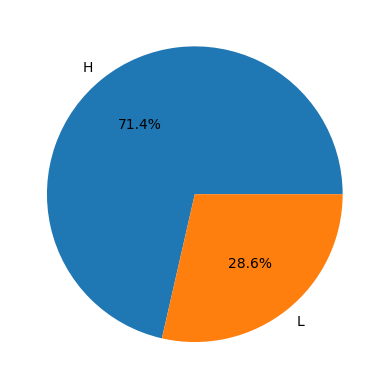

In [39]:
data = np.loadtxt('populations.txt')
column1 = data[:, 0]
column2 = data[:, 1]
column3 = data[:, 2]
column4 = data[:, 3]
mask = column2 > column3
labels = np.where(mask, "H", "L")
H_count = np.sum(labels == "H")
L_count = np.sum(labels == "L")
plt.pie([H_count, L_count], labels=["H", "L"], autopct="%1.1f%%")
plt.show()

- Plot the change in the hare population and in the lynx population for each year. Find the correlation coefficient between the both time series.

-0.17801365941182953


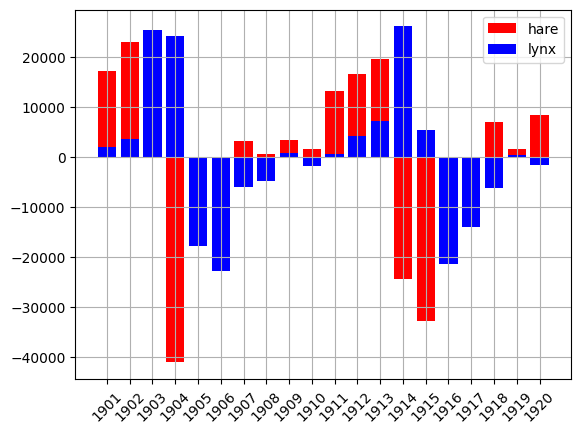

In [46]:
data = np.loadtxt('populations.txt')
column1 = data[:, 0]
column2 = data[:, 1]
column3 = data[:, 2]
column4 = data[:, 3]
column2_g = data[1:, 1]
COL2 = column2[1:] - column2[:-1]
COL3 = column3[1:] - column3[:-1]
cov_matrix=np.cov(COL2,COL3)
D2 = COL2.var(ddof=1)
D3 = COL3.var(ddof=1)
cor_matrix= cov_matrix[0,1]/(D2*D3)**0.5
print(cor_matrix)
plt.bar(column1[1:], COL2, color = 'red', label="hare")
plt.bar(column1[1:], COL3, color = 'blue', label="lynx")
plt.grid(True)
plt.xticks(column1[1:], rotation=45)
plt.legend()

- Using a scatter plot, show the population of hares vs lynxes by year (each point corresponds to a particular year, and the point coordinates correspond to the population of the two species in that year).

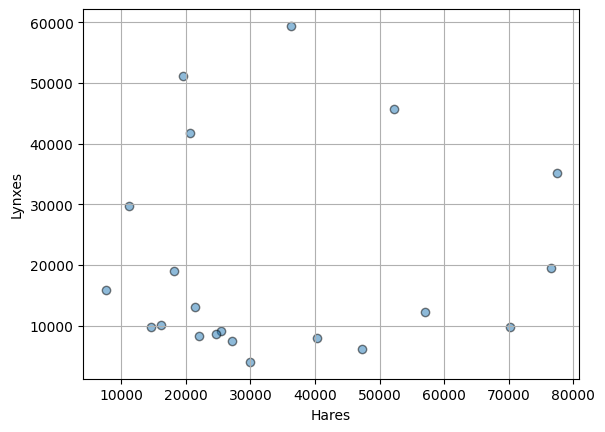

In [49]:
column2 = data[:, 1]
column3 = data[:, 2]
plt.scatter(column2, column3, alpha=0.5, edgecolors='black')
plt.xlabel("Hares")
plt.ylabel("Lynxes")
plt.grid(True)

- Assume the population of hares in 1920 is unknown. Suggest a way to estimate this value. Compare an estimated value
with the true value and print a ratio of the error to the true value.